<a href="https://colab.research.google.com/github/itagibanetos/mineracao-dados-eleitorais-2026/blob/main/02_clusterizacao_com_despesa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Parte 1 — Quanto cada candidato já gastou de campanha**


Nesta etapa, é realizada a importação dos arquivos necessários para a análise a partir do repositório criado no GitHub.

Inicialmente, foi utilizado o comando git clone para criar uma cópia do repositório mineracao-dados-eleitorais-2026 no ambiente do Google Colab. Essa etapa é necessária porque o Colab utiliza um ambiente temporário, ou seja, os arquivos podem deixar de estar disponíveis quando a sessão é encerrada ou reiniciada.

Em seguida, é usado o comando %cd para acessar a pasta do repositório clonada no caminho /content/mineracao-dados-eleitorais-2026. A partir desse momento, é possível utilizar caminhos relativos para acessar os arquivos do projeto, como a pasta dados.

Por fim, é executado o comando !ls dados para listar os arquivos presentes nessa pasta. Dessa forma, pude verificar se os arquivos de dados necessários para as etapas seguintes da análise estavam disponíveis corretamente no ambiente do Colab.

In [1]:
import sys

# Só no Google Colab: localmente os arquivos já estão na pasta do projeto
if "google.colab" in sys.modules:
    !git clone https://github.com/itagibanetos/mineracao-dados-eleitorais-2026.git
    %cd /content/mineracao-dados-eleitorais-2026

!ls dados

Graficos de analise
bem_candidato_2026.zip
candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv
candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv
consulta_cand_2026.zip
extraidos_despesas
prestacao_de_contas_eleitorais_candidatos_2026.zip


O código carrega a base de candidatos a Deputado Federal de PR, RS e SC, extrai do arquivo ZIP apenas os arquivos de despesas contratadas desses estados e processa os dados em partes para reduzir o uso de memória.

Em seguida, filtra as despesas do cargo analisado, soma o gasto contratado e conta a quantidade de despesas de cada candidato. Esses dados são unidos à base principal por meio do identificador `SQ_CANDIDATO`.

Por fim, o código cria as colunas de gasto total, quantidade de despesas, indicação de existência de despesa e gasto em escala logarítmica. A base consolidada é salva em um novo arquivo CSV para ser utilizada nas análises posteriores.

In [2]:
from pathlib import Path
from zipfile import ZipFile
import pandas as pd
import numpy as np

# =========================
# 1. Caminhos dos arquivos
# =========================
PASTA_DADOS = Path("dados")
PASTA_EXTRAIDOS = PASTA_DADOS / "extraidos_despesas"

ARQUIVO_CANDIDATOS = (
    PASTA_DADOS / "candidatos_DEPUTADO_FEDERAL_['PR', 'RS', 'SC']_2026.csv"
)

ARQUIVO_ZIP = (
    PASTA_DADOS / "prestacao_de_contas_eleitorais_candidatos_2026.zip"
)

ARQUIVO_SAIDA = (
    PASTA_DADOS / "candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv"
)

ESTADOS = ["PR", "RS", "SC"]

# =============================================
# 2. Lê a base principal dos candidatos
# =============================================
candidatos = pd.read_csv(
    ARQUIVO_CANDIDATOS,
    sep=",",
    dtype={"SQ_CANDIDATO": "string"},
    low_memory=False
)

candidatos = candidatos[
    candidatos["DS_CARGO"].str.upper().eq("DEPUTADO FEDERAL")
].copy()

# =========================================================
# 3. Localiza e descompacta somente os CSVs necessários
# =========================================================
PASTA_EXTRAIDOS.mkdir(parents=True, exist_ok=True)

arquivos_esperados = {
    f"despesas_contratadas_candidatos_2026_{uf}.csv".lower()
    for uf in ESTADOS
}

with ZipFile(ARQUIVO_ZIP, "r") as zip_ref:
    arquivos_selecionados = [
        arquivo
        for arquivo in zip_ref.namelist()
        if Path(arquivo).name.lower() in arquivos_esperados
    ]

    if len(arquivos_selecionados) != len(ESTADOS):
        raise FileNotFoundError(
            "Não encontrei os arquivos de despesas contratadas "
            "de PR, RS e SC dentro do ZIP."
        )

    arquivos_extraidos = [
        Path(zip_ref.extract(arquivo, PASTA_EXTRAIDOS))
        for arquivo in arquivos_selecionados
    ]

# =====================================================================
# 4. Processa os arquivos grandes em partes e soma por candidato
# =====================================================================
parciais = []

for arquivo in arquivos_extraidos:
    print(f"Processando: {arquivo.name}")

    leitor = pd.read_csv(
        arquivo,
        sep=";",
        encoding="latin1",
        usecols=[
            "DS_CARGO",
            "SQ_CANDIDATO",
            "SQ_DESPESA",
            "VR_DESPESA_CONTRATADA"
        ],
        dtype={
            "DS_CARGO": "string",
            "SQ_CANDIDATO": "string",
            "SQ_DESPESA": "string",
            "VR_DESPESA_CONTRATADA": "string"
        },
        chunksize=200_000,
        low_memory=False
    )

    for parte in leitor:
        parte = parte[
            parte["DS_CARGO"].str.upper().eq("DEPUTADO FEDERAL")
        ].copy()

        parte["VR_DESPESA_CONTRATADA"] = pd.to_numeric(
            parte["VR_DESPESA_CONTRATADA"]
            .str.replace(".", "", regex=False)
            .str.replace(",", ".", regex=False),
            errors="coerce"
        ).fillna(0)

        parcial = (
            parte
            .groupby("SQ_CANDIDATO", as_index=False)
            .agg(
                Total_Gasto_Campanha=(
                    "VR_DESPESA_CONTRATADA", "sum"
                ),
                QTD_DESPESAS_CONTRATADAS=(
                    "SQ_DESPESA", "count"
                )
            )
        )

        parciais.append(parcial)

# Consolida PR, RS e SC
totais_despesas = (
    pd.concat(parciais, ignore_index=True)
    .groupby("SQ_CANDIDATO", as_index=False)
    .agg(
        Total_Gasto_Campanha=(
            "Total_Gasto_Campanha", "sum"
        ),
        QTD_DESPESAS_CONTRATADAS=(
            "QTD_DESPESAS_CONTRATADAS", "sum"
        )
    )
)

# =====================================================
# 5. Une os gastos ao arquivo principal de candidatos
# =====================================================
resultado = candidatos.merge(
    totais_despesas,
    on="SQ_CANDIDATO",
    how="left"
)

resultado["TEM_DESPESA_CONTRATADA"] = (
    resultado["Total_Gasto_Campanha"].notna()
)

resultado["Total_Gasto_Campanha"] = (
    resultado["Total_Gasto_Campanha"].fillna(0)
)

resultado["QTD_DESPESAS_CONTRATADAS"] = (
    resultado["QTD_DESPESAS_CONTRATADAS"].fillna(0).astype(int)
)

# Nova variável com transformação logarítmica
resultado["Total_Gasto_Campanha_Log"] = np.log1p(
    resultado["Total_Gasto_Campanha"]
)

# ======================================
# 6. Gera o CSV para as novas análises
# ======================================
resultado.to_csv(
    ARQUIVO_SAIDA,
    index=False,
    encoding="utf-8-sig"
)

print(f"Arquivo criado: {ARQUIVO_SAIDA}")
display(
    resultado[
        [
            "SG_UF",
            "NM_CANDIDATO",
            "Total_Gasto_Campanha",
            "Total_Gasto_Campanha_Log",
            "QTD_DESPESAS_CONTRATADAS"
        ]
    ].head()
)

Processando: despesas_contratadas_candidatos_2026_PR.csv


Processando: despesas_contratadas_candidatos_2026_RS.csv


Processando: despesas_contratadas_candidatos_2026_SC.csv


Arquivo criado: dados/candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv


,SG_UF,NM_CANDIDATO,Total_Gasto_Campanha,Total_Gasto_Campanha_Log,QTD_DESPESAS_CONTRATADAS
0,PR,MARIO SETO TAKEGUMA JUNIOR,34140.0,10.438254,16
1,PR,ANTÔNIO FERNANDO TEIGAO,59862.86,10.999828,35
2,PR,CAMILLA DE MORAES GONDA,283738.41,12.555812,59
3,PR,CHARLESTON ROBERTO DE OLIVEIRA MAYER JUNIOR,0.0,0.0,1
4,PR,OMAR RAIMUNDO PICHETH NETO,144017.53,11.877697,48


In [ ]:

import matplotlib.pyplot as plt
import seaborn as sns
# 1. Definir as colunas numéricas que você deseja plotar
colunas_numericas = ['Total_Gasto_Campanha', 'Total_Gasto_Campanha_Log', 'QTD_DESPESAS_CONTRATADAS']

# 2. Configuração da grade de subplots (igual ao seu modelo)
n = len(colunas_numericas)
ncols = 3
nrows = -(-n // ncols)  # arredonda pra cima

fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))

# Garante que 'axes' seja iterável caso haja apenas 1 linha/coluna
if nrows * ncols == 1:
    axes = [axes]
else:
    axes = axes.flatten()

# 3. Loop para plotar o histograma de cada variável
for i, col in enumerate(colunas_numericas):
    sns.histplot(resultado[col], bins=25, ax=axes[i], color='#3498db')
    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

# Remove eventuais subplots vazios da grade
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição das variáveis numéricas', y=1.02, fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

O código carrega a base consolidada de candidatos com as despesas de campanha e transforma a variável de escolaridade em anos de estudo, utilizando uma tabela de correspondência entre cada nível de instrução e sua quantidade estimada de anos de estudo.

Em seguida, seleciona as variáveis `IDADE`, `ANOS_ESTUDO`, `Total_Bens_Log` e `Total_Gasto_Campanha_Log` para a nova análise. Os registros com valores ausentes, inválidos ou sem informação de escolaridade são removidos.

Depois, as variáveis são padronizadas para que tenham a mesma escala e nenhuma delas exerça influência maior apenas por possuir valores numericamente mais altos.

O código executa o algoritmo K-means para diferentes quantidades de clusters, variando de 2 a 19 grupos. Para cada valor de `k`, calcula o WCSS, utilizado no método do cotovelo, e o índice silhouette, utilizado para avaliar a separação entre os clusters.

Por fim, são gerados um gráfico comparando o cotovelo e o silhouette, uma tabela com os resultados e uma listagem dos valores calculados para cada quantidade de clusters. Esses resultados permitem verificar se a inclusão do gasto de campanha altera a quantidade mais adequada de clusters para a análise.

Candidatos sem correspondência de escolaridade: 0
Registros utilizados na análise: 1,117


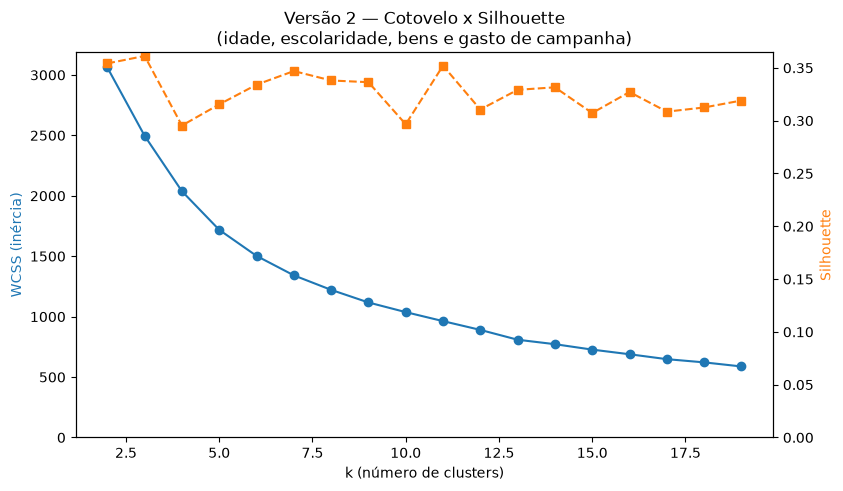

,k,WCSS,Silhouette
0,2,3062.103436,0.354206
1,3,2496.535013,0.361250
2,4,2037.956545,0.295375
3,5,1718.380490,0.315409
4,6,1502.773229,0.334056
5,7,1341.770642,0.346961
6,8,1221.716148,0.338039
7,9,1117.419772,0.336439
8,10,1037.491754,0.296613
9,11,962.996813,0.352052


k=2 | WCSS=3062.103 | silhouette=0.354
k=3 | WCSS=2496.535 | silhouette=0.361
k=4 | WCSS=2037.957 | silhouette=0.295
k=5 | WCSS=1718.380 | silhouette=0.315
k=6 | WCSS=1502.773 | silhouette=0.334
k=7 | WCSS=1341.771 | silhouette=0.347
k=8 | WCSS=1221.716 | silhouette=0.338
k=9 | WCSS=1117.420 | silhouette=0.336
k=10 | WCSS=1037.492 | silhouette=0.297
k=11 | WCSS=962.997 | silhouette=0.352
k=12 | WCSS=890.348 | silhouette=0.311
k=13 | WCSS=808.968 | silhouette=0.329
k=14 | WCSS=772.115 | silhouette=0.332
k=15 | WCSS=727.239 | silhouette=0.307
k=16 | WCSS=688.865 | silhouette=0.327
k=17 | WCSS=648.219 | silhouette=0.309
k=18 | WCSS=621.673 | silhouette=0.312
k=19 | WCSS=587.833 | silhouette=0.319


In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

SEMENTE = 42

# Arquivo gerado na etapa anterior
ARQUIVO_DADOS = Path(
    "dados/candidatos_deputado_federal_PR_RS_SC_2026_com_despesas.csv"
)

# Carrega a base
df = pd.read_csv(
    ARQUIVO_DADOS,
    encoding="utf-8-sig",
    low_memory=False
)

# Converte escolaridade em anos de estudo
ANOS_ESTUDO_POR_GRAU = {
    "ANALFABETO": 0,
    "LÊ E ESCREVE": 1,
    "ENSINO FUNDAMENTAL INCOMPLETO": 4,
    "ENSINO FUNDAMENTAL COMPLETO": 8,
    "ENSINO MÉDIO INCOMPLETO": 9,
    "ENSINO MÉDIO COMPLETO": 11,
    "SUPERIOR INCOMPLETO": 13,
    "SUPERIOR COMPLETO": 16,
}

df["ANOS_ESTUDO"] = (
    df["DS_GRAU_INSTRUCAO"]
    .astype("string")
    .str.strip()
    .str.upper()
    .map(ANOS_ESTUDO_POR_GRAU)
)

print(
    "Candidatos sem correspondência de escolaridade:",
    df["ANOS_ESTUDO"].isna().sum()
)

# Variáveis da nova análise
variaveis_v2 = [
    "IDADE",
    "ANOS_ESTUDO",
    "Total_Bens_Log",
    "Total_Gasto_Campanha_Log"
]

# Remove registros sem informação suficiente para a clusterização
dados_v2 = (
    df[variaveis_v2]
    .replace([np.inf, -np.inf], np.nan)
    .dropna()
    .copy()
)

print(f"Registros utilizados na análise: {len(dados_v2):,}")

# Padroniza as variáveis
scaler_v2 = StandardScaler()
X_v2 = scaler_v2.fit_transform(dados_v2)

# Testa valores de k entre 2 e 19
wcss_v2, sil_v2 = [], []
faixa_k = range(2, 20)

for k in faixa_k:
    km = KMeans(
        n_clusters=k,
        random_state=SEMENTE,
        n_init=10
    )

    labels = km.fit_predict(X_v2)

    wcss_v2.append(km.inertia_)
    sil_v2.append(silhouette_score(X_v2, labels))

# Gráfico de cotovelo e silhouette
fig, ax1 = plt.subplots(figsize=(9, 5))

ax1.plot(
    list(faixa_k),
    wcss_v2,
    marker="o",
    color="tab:blue"
)

ax1.set_xlabel("k (número de clusters)")
ax1.set_ylabel("WCSS (inércia)", color="tab:blue")
ax1.set_ylim(bottom=0)
ax1.set_title(
    "Versão 2 — Cotovelo x Silhouette\n"
    "(idade, escolaridade, bens e gasto de campanha)"
)

ax2 = ax1.twinx()

ax2.plot(
    list(faixa_k),
    sil_v2,
    marker="s",
    linestyle="--",
    color="tab:orange"
)

ax2.set_ylabel("Silhouette", color="tab:orange")
ax2.set_ylim(bottom=min(0, min(sil_v2)))

plt.show()

# Tabela com os resultados
resultado_k_v2 = pd.DataFrame({
    "k": list(faixa_k),
    "WCSS": wcss_v2,
    "Silhouette": sil_v2
})

display(resultado_k_v2)

for k, w, s in zip(faixa_k, wcss_v2, sil_v2):
    print(f"k={k} | WCSS={w:.3f} | silhouette={s:.3f}")

O código aplica o algoritmo K-means utilizando a quantidade final de clusters definida a partir da análise anterior de cotovelo e silhouette.

Inicialmente, são recuperados apenas os registros que foram utilizados na etapa de padronização das variáveis. Isso garante que a clusterização seja aplicada exatamente aos candidatos que possuem informações completas de idade, escolaridade, patrimônio e gasto de campanha.

Em seguida, o algoritmo K-means é executado sobre a matriz padronizada X_v2. O resultado atribui um número de cluster a cada candidato. Esses números são convertidos em letras, de modo que os grupos passem a ser identificados como Cluster A, Cluster B, Cluster C, Cluster D, Cluster E e Cluster F.

Também é criada uma paleta fixa de cores para os clusters. Essa paleta será reutilizada nos gráficos posteriores, permitindo que cada cluster mantenha a mesma cor durante toda a análise.

Por fim, o código calcula e exibe a quantidade de candidatos presente em cada cluster, além de informar o valor de k escolhido e o total de candidatos utilizados na clusterização.

In [4]:
import seaborn as sns
from sklearn.cluster import KMeans

# Escolha o k definido a partir do gráfico anterior
k_final_v2 = 6

# Recupera os registros usados para criar X_v2
df_cluster_v2 = df.loc[dados_v2.index].copy()

# Aplica K-means às variáveis padronizadas
kmeans_v2 = KMeans(
    n_clusters=k_final_v2,
    random_state=SEMENTE,
    n_init=10
)

df_cluster_v2["cluster"] = kmeans_v2.fit_predict(X_v2)

# Troca 0, 1, 2... por A, B, C...
df_cluster_v2["cluster"] = df_cluster_v2["cluster"].map(
    lambda x: chr(65 + x)
)

# Paleta fixa para os gráficos seguintes
clusters_ordenados_v2 = sorted(df_cluster_v2["cluster"].unique())

cores_cluster_v2 = dict(
    zip(
        clusters_ordenados_v2,
        sns.color_palette(
            "Set2",
            n_colors=len(clusters_ordenados_v2)
        )
    )
)

# Quantidade de candidatos por cluster
resumo_clusters_v2 = (
    df_cluster_v2["cluster"]
    .value_counts()
    .sort_index()
    .rename("Quantidade de candidatos")
)

display(resumo_clusters_v2)

print(f"K escolhido: {k_final_v2}")
print(f"Total de candidatos clusterizados: {len(df_cluster_v2):,}")

cluster
A    105
B    311
C    186
D    128
E    254
F    133
Name: Quantidade de candidatos, dtype: int64

K escolhido: 6
Total de candidatos clusterizados: 1,117


O código gera um resumo estatístico para interpretar as características de cada cluster criado pelo algoritmo K-means.

Para cada grupo, são calculados a quantidade de candidatos, a idade média, a média de anos de estudo, o patrimônio mediano, o gasto mediano e médio de campanha, além do percentual de candidatos sem gastos contratados registrados. Os valores são arredondados para uma casa decimal, facilitando a leitura e a comparação entre os clusters.

Em seguida, o código recupera os centróides gerados pelo K-means. Como o algoritmo foi aplicado sobre dados padronizados, os centróides inicialmente estão em uma escala transformada. Por esse motivo, é aplicada a transformação inversa utilizando o `scaler_v2`.

Após essa transformação, os centróides voltam a representar as escalas utilizadas nas variáveis originais: idade, anos de estudo, patrimônio em escala logarítmica e gasto de campanha em escala logarítmica.

Por fim, os centróides recebem as identificações A a F e são apresentados em uma tabela. Essa tabela permite comparar o perfil médio de cada cluster nas quatro variáveis utilizadas pela clusterização.

In [5]:
# Resumo interpretável de cada cluster
resumo_driver_v2 = (
    df_cluster_v2
    .groupby("cluster")
    .agg(
        qtd_candidatos=("SQ_CANDIDATO", "count"),
        idade_media=("IDADE", "mean"),
        anos_estudo_medio=("ANOS_ESTUDO", "mean"),
        patrimonio_mediano=("Total_Bens", "median"),
        gasto_campanha_mediano=("Total_Gasto_Campanha", "median"),
        gasto_campanha_medio=("Total_Gasto_Campanha", "mean"),
        pct_sem_gasto_contratado=(
            "Total_Gasto_Campanha",
            lambda serie: (serie == 0).mean() * 100
        )
    )
    .round(1)
)

display(resumo_driver_v2)

# Centróides nas escalas originais das quatro variáveis usadas no K-means
centroides_norm_v2 = kmeans_v2.cluster_centers_

centroides_naturais_v2 = scaler_v2.inverse_transform(
    centroides_norm_v2
)

df_centroides_v2 = pd.DataFrame(
    centroides_naturais_v2,
    columns=variaveis_v2
)

df_centroides_v2.index = [
    chr(65 + i) for i in range(k_final_v2)
]

df_centroides_v2.index.name = "cluster"

display(df_centroides_v2.round(2))

,qtd_candidatos,idade_media,anos_estudo_medio,patrimonio_mediano,gasto_campanha_mediano,gasto_campanha_medio,pct_sem_gasto_contratado
cluster,,,,,,,
A,105,47.9,8.9,0.0,0.0,1828.7,84.8
B,311,40.4,15.7,319900.0,66240.0,322696.1,0.0
C,186,44.5,13.6,0.0,27631.5,79568.9,0.0
D,128,48.9,14.6,78500.0,0.0,1.1,96.9
E,254,61.7,15.7,797677.6,138207.9,430985.6,0.0
F,133,48.9,10.9,250000.0,39752.5,152274.9,0.0


,IDADE,ANOS_ESTUDO,Total_Bens_Log,Total_Gasto_Campanha_Log
cluster,,,,
A,47.88,8.94,1.38,1.09
B,40.37,15.70,12.54,11.19
C,44.47,13.59,0.09,10.12
D,48.91,14.57,9.07,0.11
E,61.68,15.66,13.53,11.80
F,48.95,10.85,12.07,10.57


O código permite definir manualmente a quantidade de clusters que será utilizada na análise por meio da variável `K_FINAL`. Após informar esse valor, o algoritmo K-means é executado novamente utilizando as variáveis padronizadas de idade, anos de estudo, patrimônio e gasto de campanha.

Os candidatos utilizados na clusterização são organizados em grupos identificados por letras, como Cluster A, Cluster B, Cluster C e assim por diante. Também é criada uma paleta de cores fixa para que cada cluster mantenha a mesma cor nos gráficos gerados.

Em seguida, o código recupera os centróides de cada cluster e normaliza seus valores entre 0 e 1. Essa normalização é necessária para permitir a comparação visual das variáveis no gráfico de radar, pois elas possuem escalas diferentes.

Por fim, são gerados dois tipos de visualização: um gráfico de radar com todos os clusters sobrepostos e gráficos individuais para cada cluster. O código também exibe a quantidade de candidatos presente em cada grupo formado.

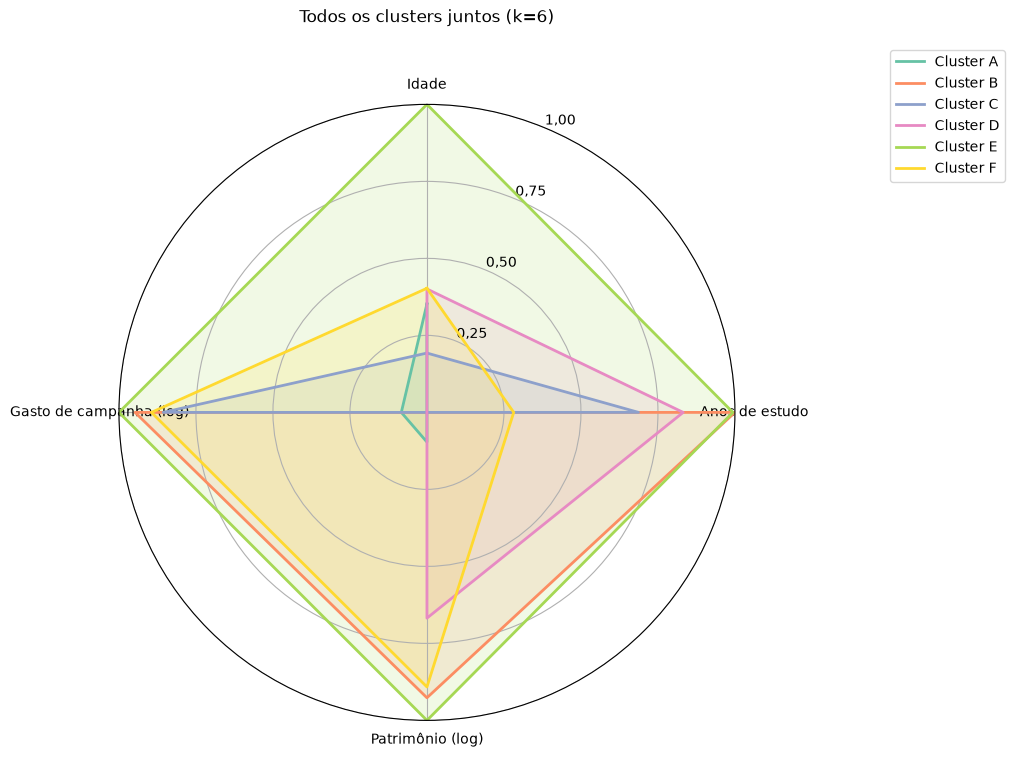

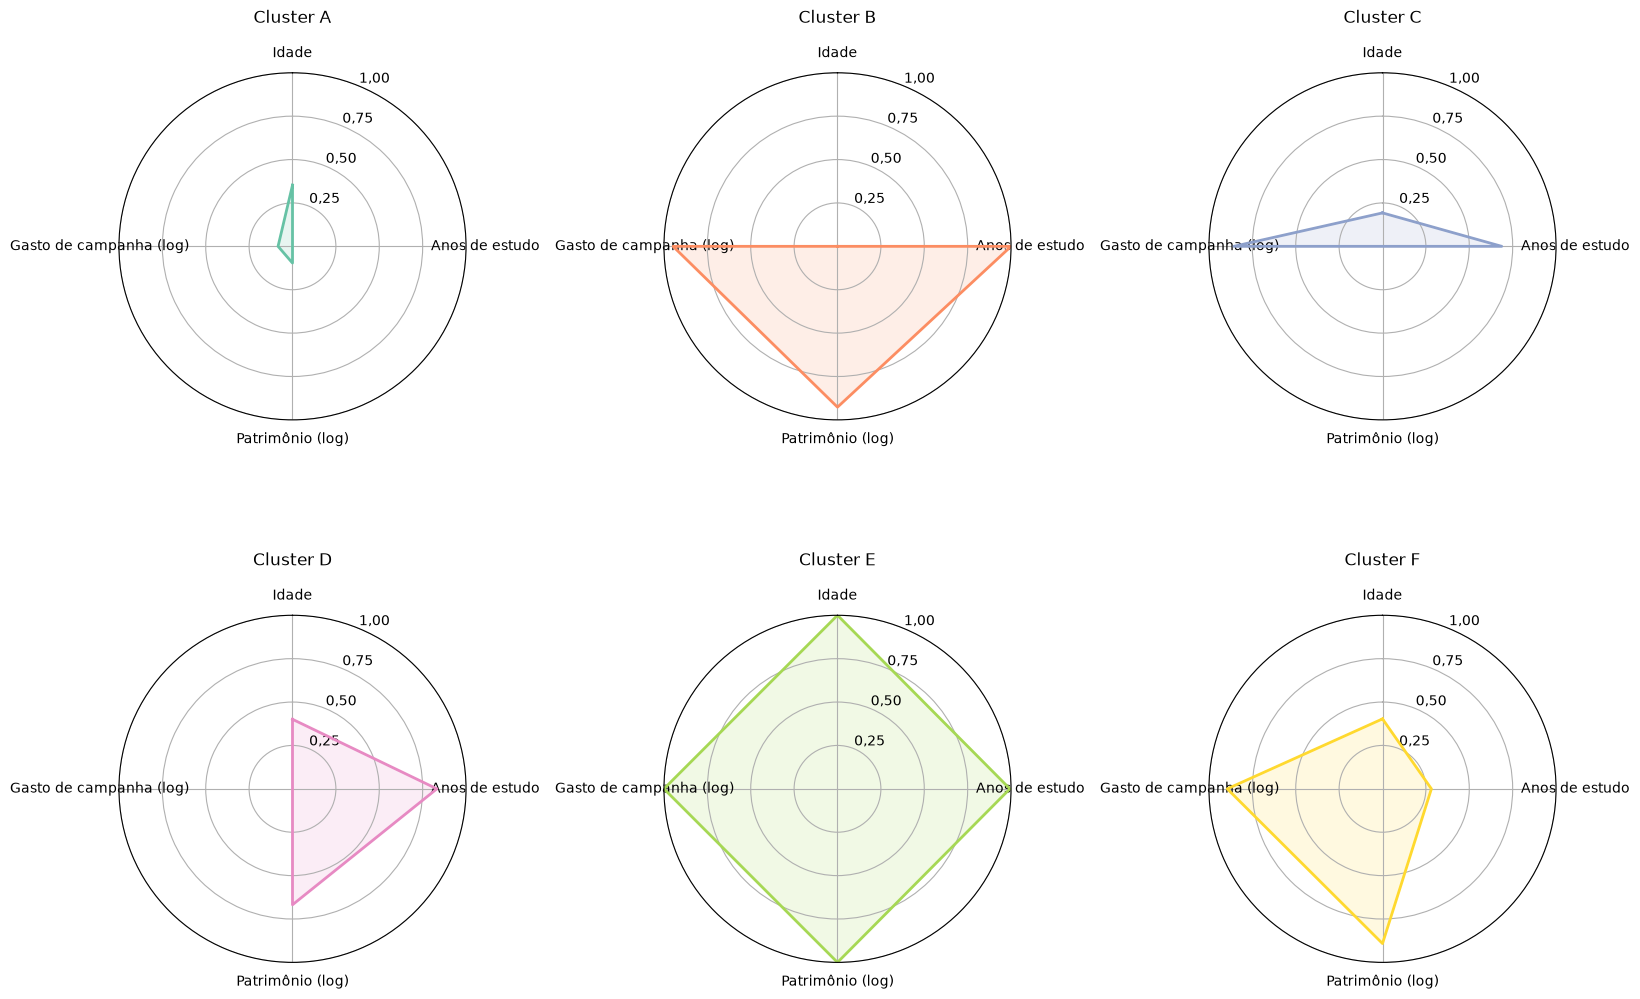

cluster
A    105
B    311
C    186
D    128
E    254
F    133
Name: Quantidade de candidatos, dtype: int64

In [6]:
from math import pi

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler

# ==================================================
# Informe aqui a quantidade de clusters desejada
# ==================================================
K_FINAL = 6

if K_FINAL < 2 or K_FINAL > len(dados_v2):
    raise ValueError("Informe um valor de K entre 2 e a quantidade de registros.")

# Recupera os candidatos utilizados na clusterização
df_cluster_v2 = df.loc[dados_v2.index].copy()

# Aplica novamente o K-means com o K informado
kmeans_v2 = KMeans(
    n_clusters=K_FINAL,
    random_state=SEMENTE,
    n_init=10
)

df_cluster_v2["cluster"] = kmeans_v2.fit_predict(X_v2)

# Converte os números dos clusters em letras: A, B, C...
df_cluster_v2["cluster"] = df_cluster_v2["cluster"].map(
    lambda x: chr(65 + x)
)

clusters_ordenados_v2 = sorted(df_cluster_v2["cluster"].unique())

# Define uma cor fixa para cada cluster
cores_cluster_v2 = dict(
    zip(
        clusters_ordenados_v2,
        sns.color_palette(
            "Set2",
            n_colors=K_FINAL
        )
    )
)

# Centróides originais das variáveis usadas no K-means
centroides_norm_v2 = kmeans_v2.cluster_centers_

centroides_naturais_v2 = scaler_v2.inverse_transform(
    centroides_norm_v2
)

# Normaliza os centróides entre 0 e 1 somente para o gráfico radar
scaler_radar_v2 = MinMaxScaler()

centros_radar_v2 = scaler_radar_v2.fit_transform(
    centroides_naturais_v2
)

labels_eixos_v2 = [
    "Idade",
    "Anos de estudo",
    "Patrimônio (log)",
    "Gasto de campanha (log)"
]

# Função para criar o gráfico radar
def plot_radar(ax, centros, labels_eixos, labels_series, cores, titulo):
    n_eixos = len(labels_eixos)

    angulos = [
        n / float(n_eixos) * 2 * pi
        for n in range(n_eixos)
    ]

    angulos += angulos[:1]

    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angulos[:-1])
    ax.set_xticklabels(labels_eixos)

    ax.set_ylim(0, 1)
    ax.set_yticks([0.25, 0.50, 0.75, 1.00])
    ax.set_yticklabels(["0,25", "0,50", "0,75", "1,00"])

    for i, linha in enumerate(centros):
        valores = list(linha) + [linha[0]]
        cor = cores[labels_series[i]]

        ax.plot(
            angulos,
            valores,
            linewidth=2,
            label=f"Cluster {labels_series[i]}",
            color=cor
        )

        ax.fill(
            angulos,
            valores,
            alpha=0.15,
            color=cor
        )

    ax.set_title(titulo, y=1.12)


# ==================================================
# Radar com todos os clusters
# ==================================================
fig, ax = plt.subplots(
    figsize=(8, 8),
    subplot_kw=dict(polar=True)
)

plot_radar(
    ax,
    centros_radar_v2,
    labels_eixos_v2,
    clusters_ordenados_v2,
    cores_cluster_v2,
    f"Todos os clusters juntos (k={K_FINAL})"
)

ax.legend(
    loc="upper right",
    bbox_to_anchor=(1.45, 1.10)
)

plt.show()


# ==================================================
# Um gráfico radar para cada cluster
# ==================================================
ncols = min(K_FINAL, 3)
nrows = -(-K_FINAL // ncols)

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(5.5 * ncols, 5.5 * nrows),
    subplot_kw=dict(polar=True)
)

axes = np.atleast_1d(axes).ravel()

for i, cluster in enumerate(clusters_ordenados_v2):
    plot_radar(
        axes[i],
        [centros_radar_v2[i]],
        labels_eixos_v2,
        [cluster],
        cores_cluster_v2,
        f"Cluster {cluster}"
    )

# Remove espaços vazios do gráfico
for j in range(len(clusters_ordenados_v2), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


# Quantidade de candidatos em cada cluster
display(
    df_cluster_v2["cluster"]
    .value_counts()
    .sort_index()
    .rename("Quantidade de candidatos")
)

## **A pergunta de verdade: incluir Total_Gasto_Campanha_Log como uma 4ª variável-driver (junto com IDADE, ANOS_ESTUDO, Total_Bens_Log) muda os clusters da Fase 2? Quem gasta mais é o mesmo grupo de quem tem mais patrimônio, ou gasto de campanha é uma dimensão diferente de patrimônio pessoal?**

A inclusão de Gastos de Campanha como quarta variável-driver altera os clusters da Fase 2, porque introduz uma dimensão que não se confunde totalmente com patrimônio. Embora exista correlação parcial entre riqueza e gasto (r = 0,37 entre os logs), os gráficos mostram que há grupos que gastam muito sem serem os mais abastados — o cluster C do K-Means acima, por exemplo, tem patrimônio mediano zero e gasto mediano de R$ 27,6 mil. Portanto, gasto de campanha é uma dimensão diferente de patrimônio pessoal e contribui para redefinir os perfis dos clusters.

Por isso, a clusterização **oficial** do projeto (Parte 3, abaixo) usa o Bisecting K-Means com as quatro variáveis.

# **Parte 2 — Uma variável categórica por quartil, pra cada variável numérica do modelo**


In [7]:
import pandas as pd
import numpy as np

# Copia a base com os clusters já definidos
df_cluster_regras = df_cluster_v2.copy()

# Variáveis numéricas usadas na clusterização
variaveis_quartis = [
    "IDADE",
    "ANOS_ESTUDO",
    "Total_Bens_Log",
    "Total_Gasto_Campanha_Log"
]

resumo_faixas = []

for variavel in variaveis_quartis:
    nome_faixa = f"{variavel}_Faixa"

    # Gera códigos numéricos para os quartis.
    # labels=False permite lidar corretamente com faixas removidas
    # por valores repetidos.
    codigos_quartis = pd.qcut(
        df_cluster_regras[variavel],
        q=4,
        labels=False,
        duplicates="drop"
    )

    # Identifica quantas faixas foram realmente geradas
    quantidade_faixas = int(codigos_quartis.nunique())

    if quantidade_faixas == 0:
        df_cluster_regras[nome_faixa] = pd.NA
        print(f"{variavel}: nenhuma faixa pôde ser criada.")

        continue

    # Cria nomes dinâmicos: Q1, Q2, Q3 e Q4,
    # ou menos faixas quando houver muitos valores repetidos
    nomes_quartis = [
        f"Q{i + 1}"
        for i in range(quantidade_faixas)
    ]

    mapa_quartis = {
        i: f"Q{i + 1}"
        for i in range(quantidade_faixas)
    }

    df_cluster_regras[nome_faixa] = pd.Categorical(
        codigos_quartis.map(mapa_quartis),
        categories=nomes_quartis,
        ordered=True
    )

    # Cria resumo da distribuição das faixas
    distribuicao = (
        df_cluster_regras[nome_faixa]
        .value_counts(dropna=False)
        .reindex(nomes_quartis, fill_value=0)
    )

    for faixa, quantidade in distribuicao.items():
        resumo_faixas.append({
            "Variavel": variavel,
            "Faixa": faixa,
            "Quantidade": quantidade,
            "Percentual": round(
                quantidade / len(df_cluster_regras) * 100,
                2
            ),
            "Qtd_Faixas_Geradas": quantidade_faixas
        })

    print(
        f"{variavel}: {quantidade_faixas} faixa(s) gerada(s) "
        f"→ {', '.join(nomes_quartis)}"
    )

# Tabela para validação e documentação
resumo_faixas_df = pd.DataFrame(resumo_faixas)

display(resumo_faixas_df)

# Confere as novas colunas criadas
display(
    df_cluster_regras[
        [
            "IDADE",
            "IDADE_Faixa",
            "ANOS_ESTUDO",
            "ANOS_ESTUDO_Faixa",
            "Total_Bens_Log",
            "Total_Bens_Log_Faixa",
            "Total_Gasto_Campanha_Log",
            "Total_Gasto_Campanha_Log_Faixa",
            "cluster"
        ]
    ].head()
)

IDADE: 4 faixa(s) gerada(s) → Q1, Q2, Q3, Q4
ANOS_ESTUDO: 2 faixa(s) gerada(s) → Q1, Q2
Total_Bens_Log: 3 faixa(s) gerada(s) → Q1, Q2, Q3
Total_Gasto_Campanha_Log: 4 faixa(s) gerada(s) → Q1, Q2, Q3, Q4


,Variavel,Faixa,Quantidade,Percentual,Qtd_Faixas_Geradas
0,IDADE,Q1,302,27.04,4
1,IDADE,Q2,278,24.89,4
2,IDADE,Q3,272,24.35,4
3,IDADE,Q4,265,23.72,4
4,ANOS_ESTUDO,Q1,437,39.12,2
5,ANOS_ESTUDO,Q2,680,60.88,2
6,Total_Bens_Log,Q1,559,50.04,3
7,Total_Bens_Log,Q2,280,25.07,3
8,Total_Bens_Log,Q3,278,24.89,3
9,Total_Gasto_Campanha_Log,Q1,280,25.07,4


,IDADE,IDADE_Faixa,ANOS_ESTUDO,ANOS_ESTUDO_Faixa,Total_Bens_Log,Total_Bens_Log_Faixa,Total_Gasto_Campanha_Log,Total_Gasto_Campanha_Log_Faixa,cluster
0,39,Q1,16,Q2,12.187977,Q2,10.438254,Q2,B
1,69,Q4,16,Q2,12.794721,Q2,10.999828,Q3,E
2,25,Q1,16,Q2,9.560198,Q1,12.555812,Q4,B
3,22,Q1,13,Q1,0.000000,Q1,0.000000,Q1,A
4,55,Q3,16,Q2,12.720954,Q2,11.877697,Q3,E


O código criou faixas categóricas por quartil para as variáveis numéricas utilizadas na clusterização: idade, anos de estudo, patrimônio em escala logarítmica e gasto de campanha em escala logarítmica.

A quantidade de faixas obtida pode ser menor que quatro quando existem muitos valores repetidos. Isso ocorreu principalmente nas variáveis `ANOS_ESTUDO` e `Total_Bens_Log`. Em anos de estudo, diversos candidatos apresentam os mesmos níveis de escolaridade, como ensino médio completo ou superior completo. Já em patrimônio, uma parcela relevante dos candidatos possui valor igual a zero.

Para evitar a separação artificial de candidatos com o mesmo valor, foi utilizado o parâmetro `duplicates='drop'`. Dessa forma, o código remove limites de quartis repetidos e mantém apenas as faixas que podem ser formadas de maneira consistente com os dados.

Como resultado, foram geradas duas faixas para anos de estudo e três faixas para patrimônio em escala logarítmica. As variáveis idade e gasto de campanha mantiveram quatro faixas. Essa decisão preserva a integridade dos dados e permite que as variáveis categorizadas sejam utilizadas posteriormente na análise de regras de associação com o algoritmo Apriori.

---
# **Parte 3 — Bisecting K-Means com as 4 variáveis (resultado oficial)**

As orientações pedem a clusterização com **Bisecting K-Means** sobre as quatro variáveis: idade, anos de estudo, patrimônio (log) e gasto de campanha (log). As Partes 1 e 2 usaram K-Means comum; o `02_clusterizacao.ipynb` rodou o Bisecting só com três variáveis (sem despesas). Aqui juntamos as duas coisas, e **este é o resultado usado nos notebooks `03` (regras de associação) e `04` (anomalias)**.

Reaproveitamos a mesma implementação manual do `02_clusterizacao.ipynb` (`bisecting_kmeans_com_historico`, critério de inércia média) e a mesma matriz `X_v2` desta página (4 variáveis, `StandardScaler`, 1.117 candidatos).

In [8]:
from sklearn.metrics import davies_bouldin_score, calinski_harabasz_score


def bisecting_kmeans_com_historico(X, k_max, criterio='inercia', random_state=SEMENTE):
    """
    Mesma implementação do 02_clusterizacao.ipynb (Parte 2): roda o Bisecting K-Means
    manualmente até k_max clusters, guardando qual cluster foi dividido em cada passo.

    criterio:
      'tamanho'  -> a cada passo, divide o cluster com MAIS pontos
      'inercia'  -> a cada passo, divide o cluster com MAIOR inércia MÉDIA (dispersão por ponto)
    """
    def inercia(indices):
        if len(indices) < 2:
            return 0.0
        pontos = X[indices]
        centro = pontos.mean(axis=0)
        return float(((pontos - centro) ** 2).sum(axis=1).mean())

    clusters = {0: np.arange(X.shape[0])}
    historico = []
    proximo_id = 1

    for nivel in range(1, k_max):
        if criterio == 'tamanho':
            id_escolhido = max(clusters, key=lambda cid: len(clusters[cid]))
        else:
            id_escolhido = max(clusters, key=lambda cid: inercia(clusters[cid]))

        indices_pai = clusters[id_escolhido]
        if len(indices_pai) < 2:
            break

        km2 = KMeans(n_clusters=2, random_state=random_state, n_init=10)
        labels2 = km2.fit_predict(X[indices_pai])
        filho_a = indices_pai[labels2 == 0]
        filho_b = indices_pai[labels2 == 1]

        id_a, id_b = proximo_id, proximo_id + 1
        proximo_id += 2

        historico.append({
            'k_resultante': nivel + 1,
            'pai_id': id_escolhido, 'pai_tamanho': len(indices_pai), 'pai_inercia': inercia(indices_pai),
            'filho_a_id': id_a, 'filho_a_tamanho': len(filho_a),
            'filho_b_id': id_b, 'filho_b_tamanho': len(filho_b),
        })

        del clusters[id_escolhido]
        clusters[id_a] = filho_a
        clusters[id_b] = filho_b

    return clusters, historico


def particao_bisecting_em_k(X, historico, k):
    """Refaz as divisões do histórico até k clusters (o KMeans com a mesma SEMENTE é
    determinístico) e devolve um rótulo por candidato: A = maior cluster, B = o seguinte..."""
    clusters_no_k = {0: np.arange(X.shape[0])}
    for h in historico:
        if h['k_resultante'] > k:
            break
        indices_pai = clusters_no_k.pop(h['pai_id'])
        labels2 = KMeans(n_clusters=2, random_state=SEMENTE, n_init=10).fit_predict(X[indices_pai])
        clusters_no_k[h['filho_a_id']] = indices_pai[labels2 == 0]
        clusters_no_k[h['filho_b_id']] = indices_pai[labels2 == 1]

    ids_por_tamanho = sorted(clusters_no_k, key=lambda cid: len(clusters_no_k[cid]), reverse=True)
    rotulos = np.empty(X.shape[0], dtype=object)
    for i, cid in enumerate(ids_por_tamanho):
        rotulos[clusters_no_k[cid]] = chr(65 + i)
    return rotulos


k_max_bisecting_v2 = 10
_, historico_bisecting_v2 = bisecting_kmeans_com_historico(X_v2, k_max_bisecting_v2, criterio='inercia')

display(pd.DataFrame(historico_bisecting_v2)[
    ['k_resultante', 'pai_tamanho', 'pai_inercia', 'filho_a_tamanho', 'filho_b_tamanho']
].round(3))

,k_resultante,pai_tamanho,pai_inercia,filho_a_tamanho,filho_b_tamanho
0,2,1117,4.000,405,712
1,3,405,4.222,222,183
2,4,183,3.516,94,89
3,5,89,2.804,50,39
4,6,222,2.637,132,90
5,7,90,2.261,49,41
6,8,41,2.046,12,29
7,9,94,2.040,46,48
8,10,712,1.899,387,325


### Dois critérios diferentes: *qual cluster dividir* × *quando parar*

É fácil confundir os dois, então vale separar:

1. **Qual cluster dividir a cada passo** — decidido pelo próprio algoritmo: o de **maior inércia média** (a tabela acima, colunas `pai_tamanho` e `pai_inercia`). Isso **não é** o método do cotovelo; só diz qual grupo está mais espalhado naquele momento.
2. **Em que k parar** — decisão nossa. Para cada k, reconstruímos a partição completa e medimos a qualidade dela como um todo, com as mesmas métricas usadas no K-Means:
   - **WCSS total** (soma das inércias de todos os clusters) → **método do cotovelo**;
   - **Silhouette** (maior = melhor);
   - **Davies-Bouldin** (menor = melhor);
   - **Calinski-Harabasz** (maior = melhor).

,k,WCSS,Silhouette,Davies_Bouldin,Calinski_Harabasz,menor_cluster,tamanhos,ganho_WCSS
0,2,3062.103,0.354,1.376,511.927,405,712 / 405,NaN
1,3,2581.102,0.345,1.399,407.191,183,712 / 222 / 183,481.001
2,4,2378.994,0.341,1.339,325.777,89,712 / 222 / 94 / 89,202.108
3,5,2284.791,0.337,1.231,265.640,39,712 / 222 / 94 / 50 / 39,94.203
4,6,2104.422,0.317,1.199,249.564,39,712 / 132 / 94 / 90 / 50 / 39,180.369
5,7,2040.714,0.300,1.223,220.044,39,712 / 132 / 94 / 50 / 49 / 41 / 39,63.708
6,8,2003.910,0.292,1.149,194.810,12,712 / 132 / 94 / 50 / 49 / 39 / 29 / 12,36.805
7,9,1930.604,0.293,1.160,182.031,12,712 / 132 / 50 / 49 / 48 / 46 / 39 / 29 / 12,73.306
8,10,1475.769,0.275,1.186,249.392,12,387 / 325 / 132 / 50 / 49 / 48 / 46 / 39 / 29 ...,454.834


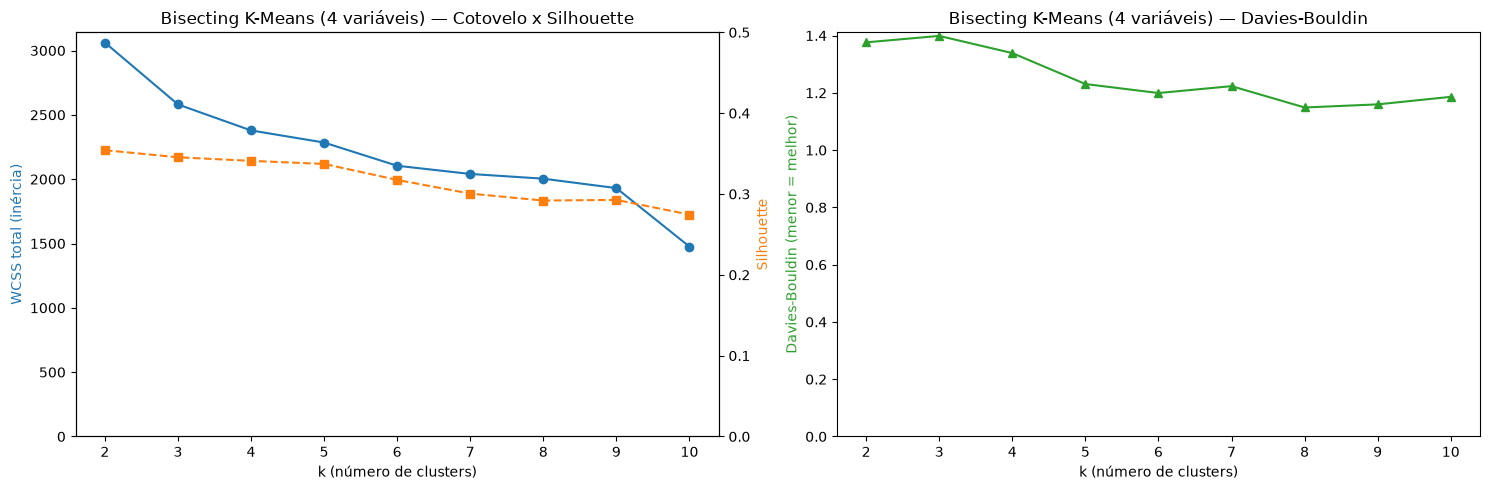

In [9]:
metricas_bisecting = []
particoes_bisecting_v2 = {}

for k in range(2, k_max_bisecting_v2 + 1):
    rotulos_k = particao_bisecting_em_k(X_v2, historico_bisecting_v2, k)
    particoes_bisecting_v2[k] = rotulos_k
    wcss_k = sum(
        ((X_v2[rotulos_k == c] - X_v2[rotulos_k == c].mean(axis=0)) ** 2).sum()
        for c in np.unique(rotulos_k)
    )
    tamanhos = pd.Series(rotulos_k).value_counts()
    metricas_bisecting.append({
        'k': k,
        'WCSS': wcss_k,
        'Silhouette': silhouette_score(X_v2, rotulos_k),
        'Davies_Bouldin': davies_bouldin_score(X_v2, rotulos_k),
        'Calinski_Harabasz': calinski_harabasz_score(X_v2, rotulos_k),
        'menor_cluster': int(tamanhos.min()),
        'tamanhos': ' / '.join(str(t) for t in tamanhos.sort_index()),
    })

metricas_bisecting = pd.DataFrame(metricas_bisecting)
metricas_bisecting['ganho_WCSS'] = -metricas_bisecting['WCSS'].diff()
display(metricas_bisecting.round(3))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax1 = axes[0]
ax1.plot(metricas_bisecting['k'], metricas_bisecting['WCSS'], marker='o', color='tab:blue')
ax1.set_xlabel('k (número de clusters)')
ax1.set_ylabel('WCSS total (inércia)', color='tab:blue')
ax1.set_ylim(bottom=0)
ax1.set_title('Bisecting K-Means (4 variáveis) — Cotovelo x Silhouette')
ax1b = ax1.twinx()
ax1b.plot(metricas_bisecting['k'], metricas_bisecting['Silhouette'], marker='s', linestyle='--', color='tab:orange')
ax1b.set_ylabel('Silhouette', color='tab:orange')
ax1b.set_ylim(0, 0.5)

ax2 = axes[1]
ax2.plot(metricas_bisecting['k'], metricas_bisecting['Davies_Bouldin'], marker='^', color='tab:green')
ax2.set_xlabel('k (número de clusters)')
ax2.set_ylabel('Davies-Bouldin (menor = melhor)', color='tab:green')
ax2.set_ylim(bottom=0)
ax2.set_title('Bisecting K-Means (4 variáveis) — Davies-Bouldin')

plt.tight_layout()
plt.show()

### Escolha do k

Escolhemos **k = 4**, cruzando três argumentos:

1. **Cotovelo.** A redução de WCSS a cada nova divisão cai rápido: 481 (k=3), 202 (k=4), 94 (k=5). Depois de k=4, cada divisão acrescenta pouca explicação. (O salto em k=10 é a primeira divisão do grupo grande de 712 candidatos, que o critério de inércia média só escolhe depois de esgotar os grupos menores.)
2. **Silhouette e Davies-Bouldin.** A silhouette quase não muda de k=2 a k=4 (0,354 → 0,345 → 0,341), e o Davies-Bouldin **melhora** em k=4 (1,339, contra 1,399 em k=3). Ou seja, a quarta divisão não piora a separação dos grupos. Para comparação, o K-Means com as mesmas 4 variáveis tem silhouette de 0,361 (k=3) e 0,295 (k=4).
3. **Interpretabilidade.** A divisão de k=4 separa, entre quem ainda não tem gasto de campanha, um grupo mais jovem e escolarizado de outro mais velho e de baixa escolaridade — dois perfis que fazem sentido separados. Já k=5 só quebra esse último grupo em pedaços de 50 e 39 candidatos (menos de 5% da base cada), sem um perfil novo.

Silhouette — Bisecting K-Means, 4 variáveis (k=4): 0.341


,qtd,idade_media,anos_estudo_medio,patrimonio_mediano,pct_sem_bens,gasto_mediano,gasto_medio,pct_sem_gasto,pct_do_total
cluster_bisecting,,,,,,,,,
A,712,50.0,15.1,506199.4,0.1,66131.0,322018.8,6.3,63.7
B,222,44.6,12.8,0.0,86.9,23728.0,70807.8,0.0,19.9
C,94,42.5,13.7,0.0,76.6,0.0,4.0,94.7,8.4
D,89,53.7,8.6,16000.0,43.8,0.0,856.7,88.8,8.0


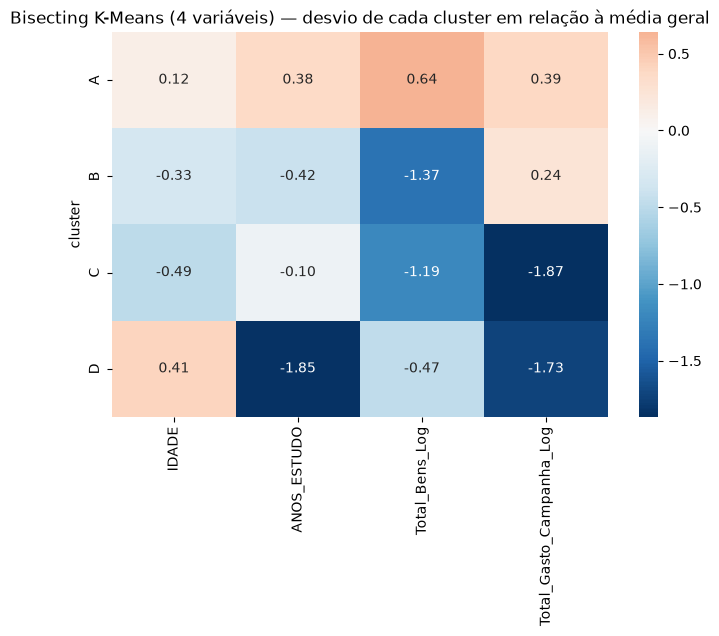

In [10]:
k_bisecting_v2 = 4

df_bisecting_v2 = df.loc[dados_v2.index].copy()
df_bisecting_v2['cluster_bisecting'] = particoes_bisecting_v2[k_bisecting_v2]
clusters_bisecting_v2 = sorted(df_bisecting_v2['cluster_bisecting'].unique())

print(f"Silhouette — Bisecting K-Means, 4 variáveis (k={k_bisecting_v2}): "
      f"{silhouette_score(X_v2, df_bisecting_v2['cluster_bisecting']):.3f}")

ficha_bisecting_v2 = df_bisecting_v2.groupby('cluster_bisecting').agg(
    qtd=('SQ_CANDIDATO', 'count'),
    idade_media=('IDADE', 'mean'),
    anos_estudo_medio=('ANOS_ESTUDO', 'mean'),
    patrimonio_mediano=('Total_Bens', 'median'),
    pct_sem_bens=('Total_Bens', lambda s: (s == 0).mean() * 100),
    gasto_mediano=('Total_Gasto_Campanha', 'median'),
    gasto_medio=('Total_Gasto_Campanha', 'mean'),
    pct_sem_gasto=('Total_Gasto_Campanha', lambda s: (s == 0).mean() * 100),
).round(1)
ficha_bisecting_v2['pct_do_total'] = (ficha_bisecting_v2['qtd'] / ficha_bisecting_v2['qtd'].sum() * 100).round(1)
display(ficha_bisecting_v2)

# Desvio de cada cluster em relação à média geral, em desvios-padrão
zscore_bisecting_v2 = (
    (df_bisecting_v2.groupby('cluster_bisecting')[variaveis_v2].mean() - dados_v2.mean()) / dados_v2.std()
)
plt.figure(figsize=(8, 1 + k_bisecting_v2))
sns.heatmap(zscore_bisecting_v2, annot=True, fmt='.2f', cmap='RdBu_r', center=0)
plt.title('Bisecting K-Means (4 variáveis) — desvio de cada cluster em relação à média geral')
plt.xlabel('')
plt.ylabel('cluster')
plt.show()

In [11]:
NOMES_CLUSTER_BISECTING = {
    'A': 'Estabelecidos com patrimônio e campanha',
    'B': 'Em campanha sem patrimônio declarado',
    'C': 'Nível superior sem campanha',
    'D': 'Base popular sem campanha',
}
df_bisecting_v2['nome_cluster_bisecting'] = df_bisecting_v2['cluster_bisecting'].map(NOMES_CLUSTER_BISECTING)
nomes_bisecting_v2 = [NOMES_CLUSTER_BISECTING[c] for c in clusters_bisecting_v2]
cores_nome_bisecting_v2 = dict(zip(nomes_bisecting_v2, sns.color_palette('Set2', n_colors=len(nomes_bisecting_v2))))

df_bisecting_v2[['cluster_bisecting', 'nome_cluster_bisecting']].value_counts().sort_index()

cluster_bisecting  nome_cluster_bisecting                 
A                  Estabelecidos com patrimônio e campanha    712
B                  Em campanha sem patrimônio declarado       222
C                  Nível superior sem campanha                 94
D                  Base popular sem campanha                   89
Name: count, dtype: int64

### Perfil dos clusters: gênero, cor/raça e estado civil

Essas variáveis **não entraram** na clusterização; servem para descrever os grupos depois de prontos.

DS_GENERO,FEMININO,MASCULINO
cluster_bisecting,,
A,32.9,67.1
B,48.6,51.4
C,40.4,59.6
D,33.7,66.3


DS_COR_RACA,AMARELA,BRANCA,INDÍGENA,PARDA,PRETA
cluster_bisecting,,,,,
A,0.7,85.3,0.0,8.6,5.5
B,0.5,63.1,1.8,16.2,18.5
C,0.0,73.4,0.0,12.8,13.8
D,0.0,73.0,0.0,13.5,13.5


DS_ESTADO_CIVIL,CASADO(A),DIVORCIADO(A),SEPARADO(A) JUDICIALMENTE,SOLTEIRO(A),VIÚVO(A)
cluster_bisecting,,,,,
A,57.2,12.2,0.7,28.4,1.5
B,30.2,14.0,1.8,51.8,2.3
C,27.7,19.1,0.0,53.2,0.0
D,39.3,16.9,2.2,36.0,5.6


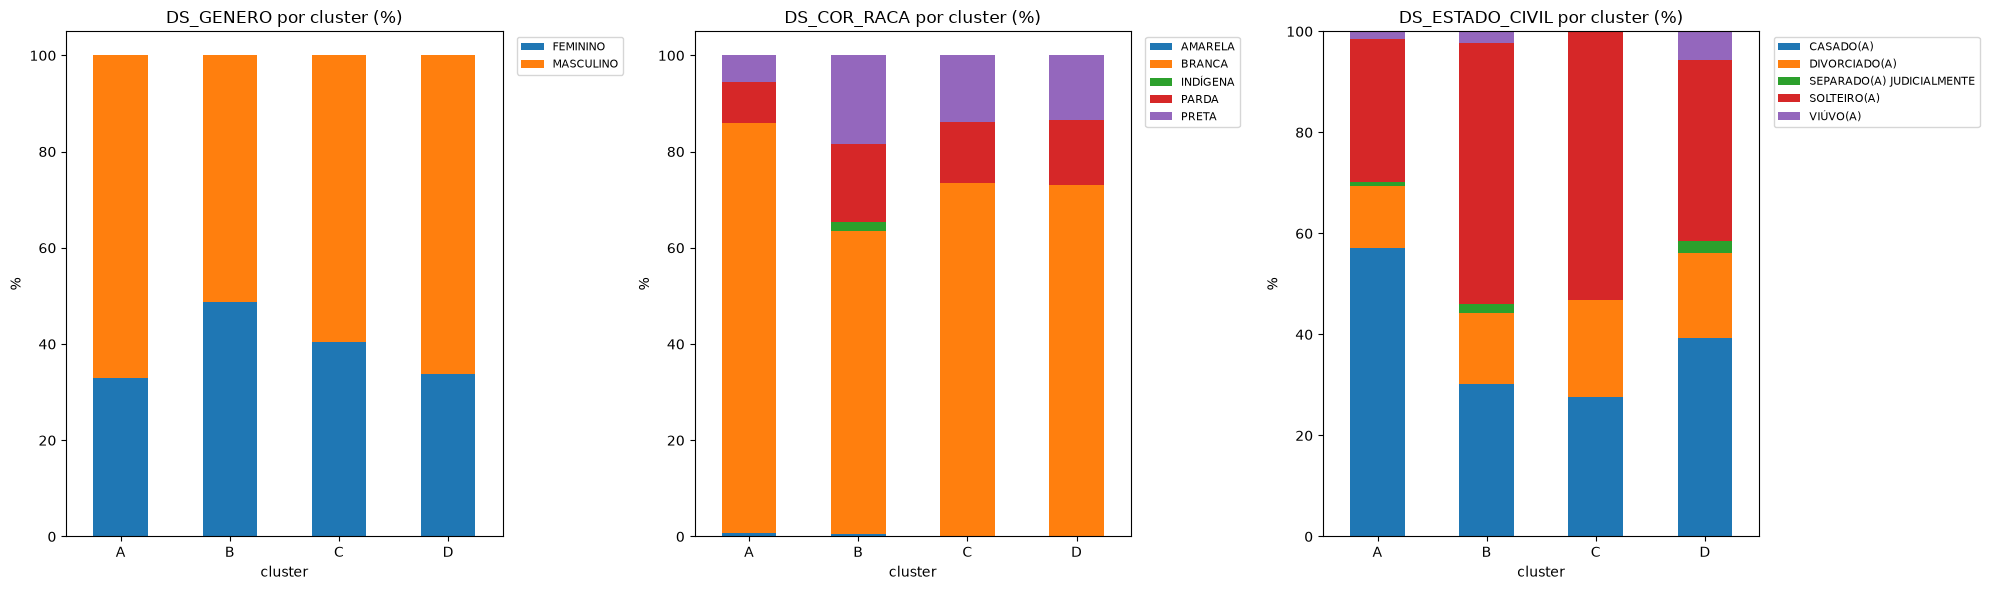

In [12]:
colunas_perfil = ['DS_GENERO', 'DS_COR_RACA', 'DS_ESTADO_CIVIL']

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for ax, col in zip(axes, colunas_perfil):
    tabela = pd.crosstab(df_bisecting_v2['cluster_bisecting'], df_bisecting_v2[col], normalize='index').mul(100)
    display(tabela.round(1))
    tabela.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'{col} por cluster (%)')
    ax.set_ylabel('%')
    ax.set_xlabel('cluster')
    ax.tick_params(axis='x', rotation=0)
    ax.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.show()

### Profissão, partido e UF

Profissão (`DS_OCUPACAO`) e partido (`SG_PARTIDO`) têm dezenas de categorias, então mostramos só as 5 mais frequentes de cada cluster.

In [13]:
for cl in clusters_bisecting_v2:
    sub = df_bisecting_v2[df_bisecting_v2['cluster_bisecting'] == cl]
    print(f"Cluster {cl} — {NOMES_CLUSTER_BISECTING[cl]} ({len(sub)} candidatos)")
    for coluna, titulo in [('DS_OCUPACAO', 'Ocupações'), ('SG_PARTIDO', 'Partidos')]:
        top5 = (sub[coluna].value_counts(normalize=True) * 100).head(5)
        print(f"  {titulo}: " + '; '.join(f"{valor} ({pct:.1f}%)" for valor, pct in top5.items()))
    print()

display(
    pd.crosstab(df_bisecting_v2['cluster_bisecting'], df_bisecting_v2['SG_UF'], normalize='index')
    .mul(100).round(1)
)

Cluster A — Estabelecidos com patrimônio e campanha (712 candidatos)
  Ocupações: EMPRESÁRIO (14.0%); ADVOGADO (10.0%); VEREADOR (8.6%); DEPUTADO (7.6%); OUTROS (7.2%)
  Partidos: PL (9.4%); PODE (9.1%); MDB (8.3%); NOVO (8.3%); REPUBLICANOS (7.6%)

Cluster B — Em campanha sem patrimônio declarado (222 candidatos)
  Ocupações: OUTROS (19.4%); EMPRESÁRIO (14.0%); ADVOGADO (5.9%); ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS (4.1%); VEREADOR (4.1%)
  Partidos: PSOL (10.4%); MISSÃO (9.5%); PSD (7.7%); PSB (7.2%); MDB (7.2%)

Cluster C — Nível superior sem campanha (94 candidatos)
  Ocupações: OUTROS (25.5%); ESTUDANTE, BOLSISTA, ESTAGIÁRIO E ASSEMELHADOS (6.4%); EMPRESÁRIO (6.4%); ADVOGADO (6.4%); ADMINISTRADOR (6.4%)
  Partidos: DC (14.9%); DEMOCRATA (11.7%); MISSÃO (10.6%); AVANTE (10.6%); PSD (8.5%)

Cluster D — Base popular sem campanha (89 candidatos)
  Ocupações: OUTROS (21.3%); COMERCIANTE (11.2%); EMPRESÁRIO (10.1%); DONA DE CASA (9.0%); APOSENTADO (EXCETO SERVIDOR PÚBLICO) (4.5

SG_UF,PR,RS,SC
cluster_bisecting,,,
A,39.9,37.9,22.2
B,34.2,42.3,23.4
C,40.4,46.8,12.8
D,33.7,56.2,10.1


### Nomes finais dos clusters (Bisecting K-Means, 4 variáveis, k=4)

Os nomes vêm da ficha técnica, do heatmap de desvio e das tabelas de perfil acima. As duas primeiras divisões da árvore explicam a lógica: o **1º corte** separa quem tem patrimônio **e** campanha (712) do resto (405); o **2º corte** separa, dentro desse resto, quem já tem gasto de campanha (222) de quem ainda não tem (183); o **3º corte** divide os sem gasto por escolaridade e idade (94 / 89).

| Cluster | n | Idade | Anos de estudo | Sem bens | Sem gasto | Nome |
|---|---|---|---|---|---|---|
| A | 712 (64%) | 50,0 | 15,1 | 0,1% | 6,3% | **Estabelecidos com patrimônio e campanha** |
| B | 222 (20%) | 44,6 | 12,8 | 86,9% | 0% | **Em campanha sem patrimônio declarado** |
| C | 94 (8%) | 42,5 | 13,7 | 76,6% | 94,7% | **Nível superior sem campanha** |
| D | 89 (8%) | 53,7 | 8,6 | 43,8% | 88,8% | **Base popular sem campanha** |

- **A — Estabelecidos com patrimônio e campanha.** Praticamente todos declaram bens (mediana de R$ 506 mil) e já têm despesas contratadas (mediana de R$ 66 mil). É o grupo mais branco (85%), mais masculino (67%) e mais casado (57%). As ocupações mais comuns são empresário, advogado, vereador e deputado: é onde estão os políticos de carreira.
- **B — Em campanha sem patrimônio declarado.** Todos já gastam (mediana de R$ 24 mil), mas 87% não declararam bens. É o grupo **mais feminino** (49%) e **menos branco** (35% pretos ou pardos). PSOL é o partido mais frequente, e estudante aparece entre as ocupações mais comuns: um perfil de candidatura militante ou de renovação, com estrutura de campanha mas sem patrimônio pessoal.
- **C — Nível superior sem campanha.** 95% sem nenhuma despesa contratada até a data do extrato e 77% sem bens declarados. O que o separa do grupo D é a escolaridade: 72% têm ensino superior completo ou incompleto (no D, só 2%). É também o grupo mais jovem (42,5 anos; 48% têm até 40 anos) e o de mais solteiros (53%). Os partidos mais comuns são pequenos (DC, Democrata, Missão, Avante).
  *Por que não "escolarizados"?* O nível superior do C é alto **em relação ao D**, não em relação à base inteira (72% contra 76% no total). As regras de associação do `03` mostram isso: o item mais associado ao C é superior **incompleto**.
- **D — Base popular sem campanha.** A menor escolaridade da base (8,6 anos; 40% com ensino médio completo, 40% só com o fundamental e nenhum com superior completo) e o grupo mais velho (53,7 anos). Também sem gasto de campanha, e metade declara algum bem de valor baixo (mediana de R$ 16 mil). As ocupações são comerciante, dona de casa e aposentado; os partidos, DC, Democrata e Agir. 56% são do RS.

> **Cuidado na leitura de "sem campanha":** o gasto vem das despesas contratadas até o extrato de 19/09/2026, com a campanha ainda em andamento. "Sem gasto" quer dizer "sem despesa registrada até essa data", e não necessariamente que a candidatura não fará campanha.